# Steam Game Market Analysis - Database Edition

This notebook performs comprehensive analysis of Steam game market data using Postgres database operations.

**Features:**
- Memory-efficient database queries for large-scale data (50M+ reviews)
- Interactive visualizations and market insights
- Genre-based filtering and analysis
- User behavior and game popularity metrics
- Market concentration analysis

**Prerequisites:**
- Run the database assembler first: `cd graph-analyser/assemble-graph-database && make run`
- Ensure `steam_reviews.db` exists in the working directory or specify the path below

## Import Required Libraries

Import necessary libraries for database operations, data analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import os
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# PostgreSQL imports
try:
    import psycopg2
    from sqlalchemy import create_engine
    print("✓ PostgreSQL drivers loaded successfully")
except ImportError as e:
    print("❌ PostgreSQL dependencies missing. Please install:")
    print("   pip install psycopg2-binary sqlalchemy")
    raise e
  
# Load environment variables from .env file
from dotenv import load_dotenv

env_file = Path("assemble-graph-database/.env")
if env_file.exists():
    load_dotenv(env_file)
    print(f"✓ Loaded environment variables from {env_file}")
else:
    print(f"⚠️  .env file not found at {env_file}")
    print("💡 Using default values")

# Configure display settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("✓ Libraries imported successfully")
print(f"✓ Pandas version: {pd.__version__}")
print(f"✓ Numpy version: {np.__version__}")

✓ PostgreSQL drivers loaded successfully
✓ Loaded environment variables from assemble-graph-database/.env
✓ Libraries imported successfully
✓ Pandas version: 2.3.2
✓ Numpy version: 2.3.2


## Database Connection Setup

Connect to the Steam reviews SQLite database and verify its structure.

In [3]:
# PostgreSQL Database connection configuration

# Database connection parameters
DB_HOST = os.getenv('DB_HOST', '127.0.0.1')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_USER = os.getenv('DB_USER', 'postgres')
DB_PASSWORD = os.getenv('DB_PASSWORD', 'postgres')
DB_NAME = os.getenv('DB_NAME', 'steam_reviews')
DB_SSLMODE = os.getenv('DB_SSLMODE', 'disable')

# PostgreSQL connection string
connection_string = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode={DB_SSLMODE}"

print(f"🐘 Connecting to PostgreSQL database:")
print(f"   Host: {DB_HOST}:{DB_PORT}")
print(f"   Database: {DB_NAME}")
print(f"   User: {DB_USER}")

# Connect to database
try:
    # Create SQLAlchemy engine for pandas integration
    engine = create_engine(connection_string)
    
    # Test connection with direct psycopg2
    conn = psycopg2.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME
    )
    
    print(f"✓ Connected to PostgreSQL database: {DB_HOST}:{DB_PORT}/{DB_NAME}")
    
    # Get database size information
    cursor = conn.cursor()
    cursor.execute("""
        SELECT pg_size_pretty(pg_database_size(%s)) as db_size;
    """, (DB_NAME,))
    db_size = cursor.fetchone()[0]
    print(f"✓ Database size: {db_size}")
    cursor.close()
    
    # For pandas compatibility, we'll use the engine for pd.read_sql_query
    # Note: conn is psycopg2 connection, engine is SQLAlchemy engine
    
except Exception as e:
    print(f"❌ Database connection failed: {e}")
    print(f"💡 Make sure PostgreSQL is running and the database exists.")
    print(f"💡 Run: cd graph-analyser/assemble-graph-database && docker compose --env-file assemble-graph-database/.env up -d")
    raise

🐘 Connecting to PostgreSQL database:
   Host: 127.0.0.1:25432
   Database: steam_reviews
   User: postgres
✓ Connected to PostgreSQL database: 127.0.0.1:25432/steam_reviews
✓ Database size: 17 GB


## Database Schema Overview

Explore the database structure and verify data integrity.

In [3]:
# Check database tables and their structure
tables_query = """
    SELECT table_name as name 
    FROM information_schema.tables 
    WHERE table_schema = 'public' AND table_type = 'BASE TABLE'
"""
tables = pd.read_sql_query(tables_query, engine)
print("📋 Database Tables:")
print(tables)

# Check table schemas
for table in tables['name'].values:
    print(f"\n📊 Table: {table}")
    schema_query = f"""
        SELECT column_name, data_type, is_nullable, column_default
        FROM information_schema.columns 
        WHERE table_name = '{table}' AND table_schema = 'public'
        ORDER BY ordinal_position
    """
    schema = pd.read_sql_query(schema_query, engine)
    print(schema.to_string(index=False))

# Get basic statistics for each table
print("\n📈 Table Row Counts:")
stats = {}
for table in tables['name'].values:
    count_query = f"SELECT COUNT(*) as count FROM {table}"
    count = pd.read_sql_query(count_query, engine).iloc[0, 0]
    stats[table] = count
    print(f"   {table}: {count:,} rows")

# Display statistics as DataFrame for better formatting
stats_df = pd.DataFrame(list(stats.items()), columns=['Table', 'Row Count'])
print("\n📊 Summary:")
print(stats_df.to_string(index=False))

📋 Database Tables:
                    name
0                  games
1                reviews
2                  users
3  user_game_connections

📊 Table: games
              column_name                   data_type is_nullable    column_default
                  game_id           character varying          NO              None
                     name                        text         YES              None
              steam_appid                     integer         YES              None
           price_currency           character varying         YES              None
              price_final                     integer         YES              None
            price_initial                     integer         YES              None
           categories_ids                       jsonb         YES              None
                genre_ids                       jsonb         YES              None
             release_date                        text         YES              None


## Dataset Statistics and Overview

Calculate comprehensive statistics about the Steam market data.

In [4]:
# Get comprehensive dataset statistics
def get_dataset_statistics(engine_or_conn):
    """Get detailed statistics about the Steam dataset"""
    
    stats_queries = {
        'Total Games': "SELECT COUNT(*) FROM games",
        'Total Users': "SELECT COUNT(*) FROM users",
        'Total Reviews': "SELECT COUNT(*) FROM reviews",
        'Positive Reviews': "SELECT COUNT(*) FROM reviews WHERE voted_up = true",
        'Negative Reviews': "SELECT COUNT(*) FROM reviews WHERE voted_up = false", 
        'Free Game Reviews': "SELECT COUNT(*) FROM reviews WHERE received_for_free = true",
        'Paid Game Reviews': "SELECT COUNT(*) FROM reviews WHERE received_for_free = false",
        'Games with Reviews': """
            SELECT COUNT(DISTINCT game_id) FROM reviews
        """,
        'Active Users': """
            SELECT COUNT(DISTINCT user_id) FROM reviews
        """,
        'Avg Reviews per Game': """
            SELECT ROUND(AVG(review_count)::numeric, 2) FROM (
                SELECT COUNT(*) as review_count FROM reviews GROUP BY game_id
            ) sub
        """,
        'Avg Reviews per User': """
            SELECT ROUND(AVG(review_count)::numeric, 2) FROM (
                SELECT COUNT(*) as review_count FROM reviews GROUP BY user_id  
            ) sub
        """
    }
    
    results = {}
    for label, query in stats_queries.items():
        try:
            result = pd.read_sql_query(query, engine_or_conn).iloc[0, 0]
            results[label] = result
        except Exception as e:
            print(f"Error with query '{label}': {e}")
            results[label] = "Error"
    
    return results

# Calculate and display statistics
print("🎮 Steam Game Market Statistics")
print("=" * 50)

stats = get_dataset_statistics(engine)
for key, value in stats.items():
    if isinstance(value, (int, float)):
        print(f"{key:.<30} {value:>15,}")
    else:
        print(f"{key:.<30} {value:>15}")

# Calculate additional metrics
positive_rate = (stats['Positive Reviews'] / stats['Total Reviews']) * 100 if stats['Total Reviews'] > 0 else 0
free_game_rate = (stats['Free Game Reviews'] / stats['Total Reviews']) * 100 if stats['Total Reviews'] > 0 else 0

print("\n📊 Key Metrics:")
print(f"{'Positive Review Rate':<30} {positive_rate:>14.1f}%")
print(f"{'Free Game Review Rate':<30} {free_game_rate:>14.1f}%")
print(f"{'Market Coverage':<30} {(stats['Games with Reviews']/stats['Total Games'])*100:>14.1f}%")

🎮 Steam Game Market Statistics
Total Games...................           98101
Total Users...................        22118178
Total Reviews.................        51091026
Positive Reviews..............        44822541
Negative Reviews..............         6268485
Free Game Reviews.............         1301796
Paid Game Reviews.............        49789230
Games with Reviews............           32970
Active Users..................        22118178
Avg Reviews per Game..........        1,549.62
Avg Reviews per User..........            2.31

📊 Key Metrics:
Positive Review Rate                     87.7%
Free Game Review Rate                     2.5%
Market Coverage                          33.6%


# Graph measures analysis

Count the number of components in the graph, number of game nodes, number of players nodes, number of edges.

In [6]:
# Graph Statistics - General Overview
print("📊 Computing Graph Statistics")
print("=" * 60)

# Import text for SQLAlchemy 2.0+
from sqlalchemy import text

# Create table to store graph statistics if it doesn't exist
print("🔧 Creating graph_statistics table...")

create_stats_table = """
  CREATE TABLE IF NOT EXISTS graph_statistics (
      id SERIAL PRIMARY KEY,
      statistic_name VARCHAR(255) UNIQUE NOT NULL,
      statistic_value NUMERIC,
      statistic_type VARCHAR(50),
      description TEXT,
      computed_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
      updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
  );
"""

with engine.begin() as connection:
    connection.execute(text(create_stats_table))

print("✓ Graph statistics table created (if not existed)")

# Count nodes and edges
graph_stats_query = """
SELECT 
    'Games' as node_type,
    COUNT(*) as node_count
FROM games
UNION ALL
SELECT 
    'Users' as node_type,
    COUNT(*) as node_count
FROM users
UNION ALL
SELECT 
    'Reviews (Edges)' as node_type,
    COUNT(*) as node_count
FROM reviews
"""

graph_stats = pd.read_sql_query(graph_stats_query, engine)
print("\n🎮 Graph Structure:")
print(graph_stats.to_string(index=False))

# Additional edge statistics
edge_stats_query = """
SELECT 
    (SELECT COUNT(DISTINCT game_id) FROM reviews) as games_with_reviews,
    (SELECT COUNT(DISTINCT user_id) FROM reviews) as active_users,
    (SELECT COUNT(*) FROM reviews) as total_edges,
    (SELECT AVG(cnt) FROM (
        SELECT COUNT(*) as cnt FROM reviews GROUP BY game_id
    ) g) as avg_edges_per_game,
    (SELECT AVG(cnt) FROM (
        SELECT COUNT(*) as cnt FROM reviews GROUP BY user_id
    ) u) as avg_edges_per_user
"""

edge_stats = pd.read_sql_query(edge_stats_query, engine)
print("\n📈 Edge Statistics:")
for col in edge_stats.columns:
    value = edge_stats[col].iloc[0]
    print(f"   {col.replace('_', ' ').title():<30} {value:,.2f}")

# Store statistics in the database
print("\n💾 Storing statistics in database...")

# Prepare statistics to insert
stats_to_insert = []

# Node counts
for _, row in graph_stats.iterrows():
    stats_to_insert.append({
        'name': row['node_type'],
        'value': row['node_count'],
        'type': 'node_count',
        'description': f"Total number of {row['node_type']} nodes in the graph"
    })

# Edge statistics
for col in edge_stats.columns:
    value = edge_stats[col].iloc[0]
    stats_to_insert.append({
        'name': col,
        'value': float(value),
        'type': 'edge_statistic',
        'description': f"{col.replace('_', ' ').title()} in the graph"
    })

# Insert or update statistics
with engine.begin() as connection:
    for stat in stats_to_insert:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Statistics stored in graph_statistics table")

# Display stored statistics
stored_stats_query = """
SELECT 
    statistic_name,
    statistic_value,
    statistic_type,
    updated_at
FROM graph_statistics
ORDER BY 
    CASE statistic_type
        WHEN 'node_count' THEN 1
        WHEN 'edge_statistic' THEN 2
        ELSE 3
    END,
    statistic_name
"""

stored_stats = pd.read_sql_query(stored_stats_query, engine)
print("\n📊 Stored Graph Statistics:")
print(stored_stats.to_string(index=False))

print(f"\n✅ Graph statistics computed and stored successfully")

📊 Computing Graph Statistics
🔧 Creating graph_statistics table...
✓ Graph statistics table created (if not existed)

🎮 Graph Structure:
      node_type  node_count
          Games       98101
          Users    22118178
Reviews (Edges)    51091026

📈 Edge Statistics:
   Games With Reviews             32,970.00
   Active Users                   22,118,178.00
   Total Edges                    51,091,026.00
   Avg Edges Per Game             1,549.62
   Avg Edges Per User             2.31

💾 Storing statistics in database...
✓ Statistics stored in graph_statistics table

📊 Stored Graph Statistics:
    statistic_name  statistic_value statistic_type                 updated_at
             Games     9.810100e+04     node_count 2025-11-02 19:43:45.723712
   Reviews (Edges)     5.109103e+07     node_count 2025-11-02 19:43:45.723712
             Users     2.211818e+07     node_count 2025-11-02 19:43:45.723712
      active_users     2.211818e+07 edge_statistic 2025-11-02 19:43:45.723712
avg_edges

### Add Degree Columns

Add degree columns to games and users tables to store node degrees (number of connections).

In [7]:
# Add degree column to games and users tables if they don't exist
print("🔧 Adding degree columns to node tables...")

# Check if columns exist and add if needed
add_columns_queries = [
    """
    ALTER TABLE games ADD COLUMN IF NOT EXISTS degree INTEGER DEFAULT 0;
    """,
    """
    ALTER TABLE users ADD COLUMN IF NOT EXISTS degree INTEGER DEFAULT 0;
    """
]

with engine.begin() as connection:
    for query in add_columns_queries:
        connection.execute(text(query))

print("✓ Degree columns added (if not existed)")

# Compute and update degrees
print("\n📊 Computing node degrees...")

update_degrees_queries = [
    """
    UPDATE games g
    SET degree = (
        SELECT COUNT(*) 
        FROM reviews r 
        WHERE r.game_id = g.game_id
    )
    """,
    """
    UPDATE users u
    SET degree = (
        SELECT COUNT(*) 
        FROM reviews r 
        WHERE r.user_id = u.user_id
    )
    """
]

with engine.begin() as connection:
    for query in update_degrees_queries:
        connection.execute(text(query))

print("✓ Node degrees computed and stored")

# Display degree statistics
degree_stats_query = """
SELECT 
    'Games' as node_type,
    COUNT(*) as nodes,
    MIN(degree) as min_degree,
    AVG(degree) as avg_degree,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY degree) as median_degree,
    MAX(degree) as max_degree,
    STDDEV(degree) as stddev_degree
FROM games
UNION ALL
SELECT 
    'Users' as node_type,
    COUNT(*) as nodes,
    MIN(degree) as min_degree,
    AVG(degree) as avg_degree,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY degree) as median_degree,
    MAX(degree) as max_degree,
    STDDEV(degree) as stddev_degree
FROM users
"""

degree_stats = pd.read_sql_query(degree_stats_query, engine)
print("\n📈 Degree Statistics:")
print(degree_stats.to_string(index=False))

# Store degree statistics in the database
print("\n💾 Storing degree statistics in graph_statistics table...")

degree_stats_to_insert = []

for _, row in degree_stats.iterrows():
    node_type = row['node_type']
    prefix = node_type.lower()
    
    degree_stats_to_insert.extend([
        {
            'name': f'{prefix}_count',
            'value': float(row['nodes']),
            'type': 'degree_statistic',
            'description': f"Total number of {node_type} nodes"
        },
        {
            'name': f'{prefix}_min_degree',
            'value': float(row['min_degree']),
            'type': 'degree_statistic',
            'description': f"Minimum degree for {node_type}"
        },
        {
            'name': f'{prefix}_avg_degree',
            'value': float(row['avg_degree']),
            'type': 'degree_statistic',
            'description': f"Average degree for {node_type}"
        },
        {
            'name': f'{prefix}_median_degree',
            'value': float(row['median_degree']),
            'type': 'degree_statistic',
            'description': f"Median degree for {node_type}"
        },
        {
            'name': f'{prefix}_max_degree',
            'value': float(row['max_degree']),
            'type': 'degree_statistic',
            'description': f"Maximum degree for {node_type}"
        },
        {
            'name': f'{prefix}_stddev_degree',
            'value': float(row['stddev_degree']) if row['stddev_degree'] is not None else 0.0,
            'type': 'degree_statistic',
            'description': f"Standard deviation of degree for {node_type}"
        }
    ])

# Insert or update degree statistics
with engine.begin() as connection:
    for stat in degree_stats_to_insert:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Degree statistics stored in graph_statistics table")

print("\n✅ Degree computation complete!")

🔧 Adding degree columns to node tables...
✓ Degree columns added (if not existed)

📊 Computing node degrees...
✓ Node degrees computed and stored

📈 Degree Statistics:
node_type    nodes  min_degree  avg_degree  median_degree  max_degree  stddev_degree
    Games    98101           0  520.800257            0.0      840001    8726.577515
    Users 22118178           1    2.309911            1.0        4116       5.162598

💾 Storing degree statistics in graph_statistics table...
✓ Degree statistics stored in graph_statistics table

✅ Degree computation complete!


### Degree Distribution Visualization

Visualize the distribution of node degrees for both games and users.

📊 Creating degree distribution visualizations...


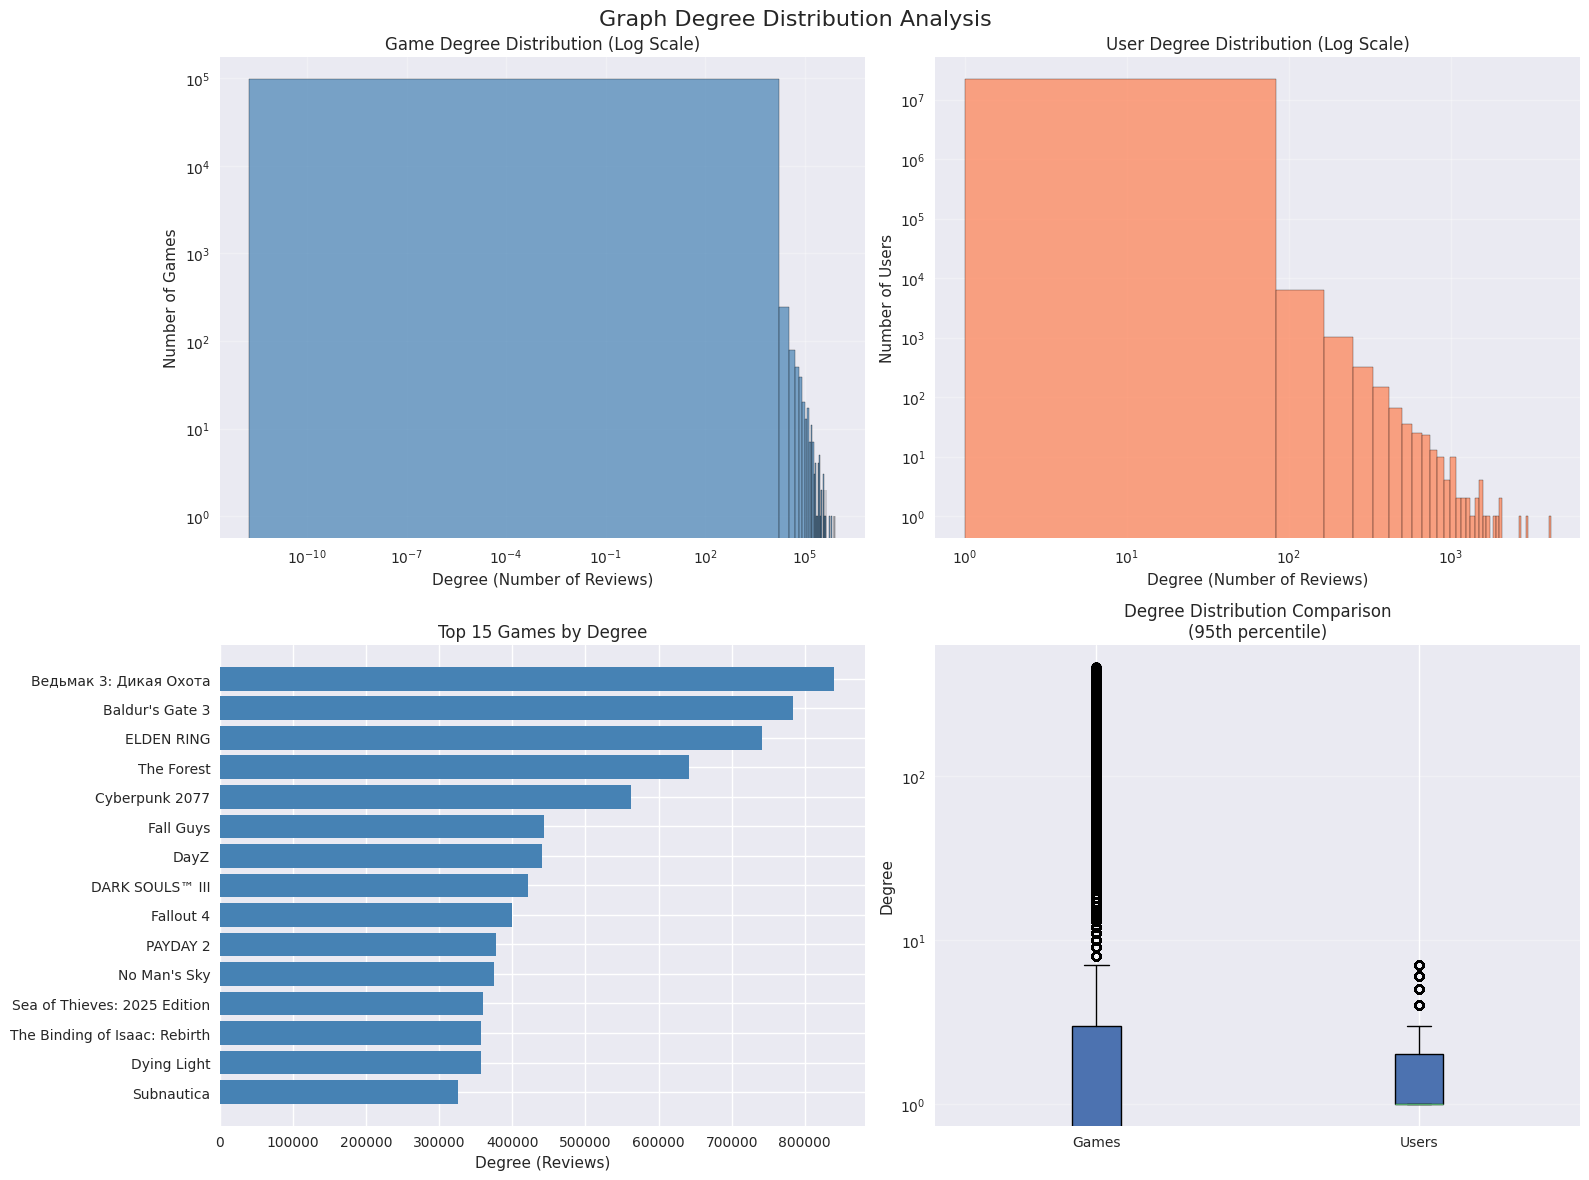

📊 Degree distribution saved to analysis_plots/degree_distribution.png
💾 Degree data exported to CSV files
💾 Degree data exported to CSV files


<Figure size 800x550 with 0 Axes>

In [8]:
# Visualize degree distributions
print("📊 Creating degree distribution visualizations...")

# Fetch degree data
game_degrees_query = "SELECT degree FROM games ORDER BY degree"
user_degrees_query = "SELECT degree FROM users ORDER BY degree"

game_degrees = pd.read_sql_query(game_degrees_query, engine)['degree'].values
user_degrees = pd.read_sql_query(user_degrees_query, engine)['degree'].values

# Create visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Graph Degree Distribution Analysis', fontsize=16, y=0.98)

# 1. Game degree distribution (log-log)
ax1.hist(game_degrees, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Degree (Number of Reviews)')
ax1.set_ylabel('Number of Games')
ax1.set_title('Game Degree Distribution (Log Scale)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# 2. User degree distribution (log-log)
ax2.hist(user_degrees, bins=50, alpha=0.7, color='coral', edgecolor='black')
ax2.set_xlabel('Degree (Number of Reviews)')
ax2.set_ylabel('Number of Users')
ax2.set_title('User Degree Distribution (Log Scale)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

# 3. Top games by degree
top_games_degree_query = """
SELECT name, degree 
FROM games 
WHERE degree > 0
ORDER BY degree DESC 
LIMIT 15
"""
top_games_degree = pd.read_sql_query(top_games_degree_query, engine)

ax3.barh(range(len(top_games_degree)), top_games_degree['degree'], color='steelblue')
ax3.set_yticks(range(len(top_games_degree)))
ax3.set_yticklabels([name[:30] + '...' if len(name) > 30 else name for name in top_games_degree['name']])
ax3.set_xlabel('Degree (Reviews)')
ax3.set_title('Top 15 Games by Degree')
ax3.invert_yaxis()

# 4. Degree distribution comparison (box plot)
degree_data = [game_degrees[game_degrees <= np.percentile(game_degrees, 95)],  # Filter outliers for visibility
               user_degrees[user_degrees <= np.percentile(user_degrees, 95)]]
ax4.boxplot(degree_data, labels=['Games', 'Users'], patch_artist=True)
ax4.set_ylabel('Degree')
ax4.set_title('Degree Distribution Comparison\n(95th percentile)')
ax4.set_yscale('log')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Save plot
output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'degree_distribution.png', dpi=300, bbox_inches='tight')
print(f"📊 Degree distribution saved to {output_dir / 'degree_distribution.png'}")

# Export degree data
game_degrees_df = pd.DataFrame({'degree': game_degrees})
user_degrees_df = pd.DataFrame({'degree': user_degrees})
game_degrees_df.to_csv(output_dir / 'game_degrees.csv', index=False)
user_degrees_df.to_csv(output_dir / 'user_degrees.csv', index=False)
print(f"💾 Degree data exported to CSV files")

### Connected Components Analysis

Identify and analyze connected components in the bipartite graph. Add component_id column to track which component each node belongs to.

In [ ]:
# Add component_id columns to track connected components
print("🔧 Adding component_id columns to node tables...")

add_component_columns = [
    """
      ALTER TABLE games ADD COLUMN IF NOT EXISTS component_id INTEGER;
    """,
    """
      ALTER TABLE users ADD COLUMN IF NOT EXISTS component_id INTEGER;
    """
]

with engine.begin() as connection:
    for query in add_component_columns:
        connection.execute(text(query))

print("✓ Component_id columns added (if not existed)")

# Fetch graph data for component analysis
print("\n📊 Loading graph structure for component analysis...")

size_check = pd.read_sql_query("""
    SELECT 
        (SELECT COUNT(*) FROM games) as game_count,
        (SELECT COUNT(*) FROM users) as user_count,
        (SELECT COUNT(*) FROM reviews) as edge_count
""", engine)

total_nodes = size_check['game_count'].iloc[0] + size_check['user_count'].iloc[0]
total_edges = size_check['edge_count'].iloc[0]

print(f"   Graph size: {total_nodes:,} nodes, {total_edges:,} edges")

# Create stored procedure for BFS-based component detection
print("\n🔄 Creating BFS stored procedure for component detection...")

create_bfs_procedure = """
CREATE OR REPLACE PROCEDURE compute_connected_components()
LANGUAGE plpgsql
AS $$
DECLARE
    current_component_id INTEGER := 1;
    nodes_processed INTEGER := 0;
    total_nodes INTEGER;
    current_node_id VARCHAR;
    current_node_type TEXT;
BEGIN
    -- Reset all component IDs
    UPDATE games SET component_id = NULL;
    UPDATE users SET component_id = NULL;
    
    -- Get total number of nodes
    SELECT COUNT(*) INTO total_nodes FROM (
        SELECT game_id as node_id FROM games
        UNION ALL
        SELECT user_id as node_id FROM users
    ) all_nodes;
    
    RAISE NOTICE 'Starting BFS for % total nodes', total_nodes;
    
    -- Process games first
    FOR current_node_id IN 
        SELECT game_id FROM games WHERE component_id IS NULL ORDER BY game_id
    LOOP
        -- Skip if already assigned
        CONTINUE WHEN EXISTS (SELECT 1 FROM games WHERE game_id = current_node_id AND component_id IS NOT NULL);
        
        -- Start BFS from this game node
        CREATE TEMP TABLE IF NOT EXISTS bfs_queue (
            node_id VARCHAR,
            node_type TEXT
        ) ON COMMIT DROP;
        
        -- Initialize queue with current game
        INSERT INTO bfs_queue VALUES (current_node_id, 'game');
        UPDATE games SET component_id = current_component_id WHERE game_id = current_node_id;
        
        -- BFS traversal
        WHILE EXISTS (SELECT 1 FROM bfs_queue) LOOP
            -- Get next node from queue
            SELECT node_id, node_type INTO current_node_id, current_node_type 
            FROM bfs_queue LIMIT 1;
            
            DELETE FROM bfs_queue WHERE node_id = current_node_id AND node_type = current_node_type;
            
            -- Process based on node type
            IF current_node_type = 'game' THEN
                -- Find all connected users through reviews (optimized with INNER JOIN)
                INSERT INTO bfs_queue
                SELECT DISTINCT r.user_id, 'user'
                FROM reviews r
                INNER JOIN users u ON u.user_id = r.user_id AND u.component_id IS NULL
                WHERE r.game_id = current_node_id;
                
                -- Assign component to newly discovered users
                UPDATE users u
                SET component_id = current_component_id
                FROM reviews r
                WHERE r.game_id = current_node_id
                  AND u.user_id = r.user_id
                  AND u.component_id IS NULL;
                
            ELSE  -- current_node_type = 'user'
                -- Find all connected games through reviews (optimized with INNER JOIN)
                INSERT INTO bfs_queue
                SELECT DISTINCT r.game_id, 'game'
                FROM reviews r
                INNER JOIN games g ON g.game_id = r.game_id AND g.component_id IS NULL
                WHERE r.user_id = current_node_id;
                
                -- Assign component to newly discovered games
                UPDATE games g
                SET component_id = current_component_id
                FROM reviews r
                WHERE r.user_id = current_node_id
                  AND g.game_id = r.game_id
                  AND g.component_id IS NULL;
            END IF;
        END LOOP;
        
        DROP TABLE IF EXISTS bfs_queue;
        
        -- Move to next component
        current_component_id := current_component_id + 1;
        nodes_processed := nodes_processed + 1;
        
        -- Progress update every 100 components
        IF nodes_processed % 100 = 0 THEN
            RAISE NOTICE 'Processed % components', nodes_processed;
        END IF;
    END LOOP;
    
    -- Assign component 0 to isolated nodes (nodes with no edges)
    UPDATE games SET component_id = 0 WHERE component_id IS NULL;
    UPDATE users SET component_id = 0 WHERE component_id IS NULL;
    
    RAISE NOTICE 'Component detection complete. Found % components', current_component_id - 1;
END;
$$;
"""

with engine.begin() as connection:
    connection.execute(text(create_bfs_procedure))

print("✓ BFS stored procedure created")

# Execute the procedure
print("\n⏳ Computing connected components using BFS (this may take several minutes)...")
print("   This will process all nodes and edges to find true connected components")

with engine.begin() as connection:
    connection.execute(text("CALL compute_connected_components()"))

print("✓ Component IDs assigned using BFS")

# Get component statistics
component_stats_query = """
SELECT 
    component_id,
    COUNT(CASE WHEN node_type = 'game' THEN 1 END) as game_nodes,
    COUNT(CASE WHEN node_type = 'user' THEN 1 END) as user_nodes,
    COUNT(*) as total_nodes
FROM (
    SELECT game_id as node_id, 'game' as node_type, component_id FROM games
    UNION ALL
    SELECT user_id as node_id, 'user' as node_type, component_id FROM users
) all_nodes
GROUP BY component_id
ORDER BY total_nodes DESC
"""

component_stats = pd.read_sql_query(component_stats_query, engine)
print("\n📊 Component Statistics:")
print(component_stats.to_string(index=False))

# Count edges per component
edge_component_query = """
SELECT 
    COALESCE(g.component_id, 0) as component_id,
    COUNT(*) as edge_count
FROM reviews r
JOIN games g ON r.game_id = g.game_id
GROUP BY g.component_id
ORDER BY edge_count DESC
LIMIT 10
"""

edge_component_stats = pd.read_sql_query(edge_component_query, engine)
print("\n🔗 Edges per Component (Top 10):")
print(edge_component_stats.to_string(index=False))

# Store component statistics in graph_statistics table
print("\n💾 Storing component statistics in database...")

component_stats_to_insert = []

# Total number of components
total_components = len(component_stats[component_stats['component_id'] != 0])
component_stats_to_insert.append({
    'name': 'total_components',
    'value': float(total_components),
    'type': 'component_statistic',
    'description': 'Total number of connected components (excluding isolated nodes)'
})

# Main component statistics
if len(component_stats) > 0:
    main_component = component_stats.iloc[0]
    total_all_nodes = component_stats['total_nodes'].sum()
    
    component_stats_to_insert.extend([
        {
            'name': 'main_component_nodes',
            'value': float(main_component['total_nodes']),
            'type': 'component_statistic',
            'description': 'Number of nodes in the largest connected component'
        },
        {
            'name': 'main_component_games',
            'value': float(main_component['game_nodes']),
            'type': 'component_statistic',
            'description': 'Number of game nodes in the largest connected component'
        },
        {
            'name': 'main_component_users',
            'value': float(main_component['user_nodes']),
            'type': 'component_statistic',
            'description': 'Number of user nodes in the largest connected component'
        },
        {
            'name': 'main_component_percentage',
            'value': float((main_component['total_nodes'] / total_all_nodes) * 100),
            'type': 'component_statistic',
            'description': 'Percentage of nodes in the largest connected component'
        }
    ])
    
    # Isolated nodes statistics
    isolated = component_stats[component_stats['component_id'] == 0]
    if len(isolated) > 0:
        component_stats_to_insert.extend([
            {
                'name': 'isolated_games',
                'value': float(isolated.iloc[0]['game_nodes']),
                'type': 'component_statistic',
                'description': 'Number of isolated game nodes (no reviews)'
            },
            {
                'name': 'isolated_users',
                'value': float(isolated.iloc[0]['user_nodes']),
                'type': 'component_statistic',
                'description': 'Number of isolated user nodes (no reviews)'
            }
        ])

# Insert or update component statistics
with engine.begin() as connection:
    for stat in component_stats_to_insert:
        upsert_query = """
        INSERT INTO graph_statistics (statistic_name, statistic_value, statistic_type, description, updated_at)
        VALUES (:name, :value, :type, :description, CURRENT_TIMESTAMP)
        ON CONFLICT (statistic_name) 
        DO UPDATE SET 
            statistic_value = EXCLUDED.statistic_value,
            statistic_type = EXCLUDED.statistic_type,
            description = EXCLUDED.description,
            updated_at = CURRENT_TIMESTAMP
        """
        connection.execute(text(upsert_query), stat)

print("✓ Component statistics stored in graph_statistics table")

print("\n✅ Component analysis complete!")
print(f"   Found {total_components} connected components")
print(f"   Largest component: {main_component['total_nodes']:,} nodes ({(main_component['total_nodes'] / total_all_nodes) * 100:.1f}% of total)")

🔧 Adding component_id columns to node tables...
✓ Component_id columns added (if not existed)

📊 Loading graph structure for component analysis...
   Graph size: 22,216,279 nodes, 51,091,026 edges

🔄 Creating BFS stored procedure for component detection...
✓ BFS stored procedure created

⏳ Computing connected components using BFS (this may take several minutes)...
   This will process all nodes and edges to find true connected components
   Graph size: 22,216,279 nodes, 51,091,026 edges

🔄 Creating BFS stored procedure for component detection...
✓ BFS stored procedure created

⏳ Computing connected components using BFS (this may take several minutes)...
   This will process all nodes and edges to find true connected components


### Component Distribution Visualization

Visualize the size distribution of connected components.

In [ ]:
# Visualize component structure
print("📊 Creating component visualization...")

# Create component visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Connected Components Analysis', fontsize=16, y=0.98)

# 1. Component size distribution
if len(component_stats) > 0:
    # Bar chart of component sizes
    component_sizes = component_stats['total_nodes'].values[:20]  # Top 20 components
    ax1.bar(range(len(component_sizes)), component_sizes, color='steelblue', alpha=0.7)
    ax1.set_xlabel('Component ID (sorted by size)')
    ax1.set_ylabel('Number of Nodes')
    ax1.set_title('Component Size Distribution (Top 20)')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3, axis='y')

# 2. Node type distribution in main component
if len(component_stats) > 0:
    main_component = component_stats.iloc[0]
    node_types = ['Games', 'Users']
    node_counts = [main_component['game_nodes'], main_component['user_nodes']]
    colors_pie = ['steelblue', 'coral']
    
    ax2.pie(node_counts, labels=node_types, autopct='%1.1f%%', 
            colors=colors_pie, startangle=90)
    ax2.set_title(f'Node Distribution in Main Component\nTotal: {main_component["total_nodes"]:,} nodes')

# 3. Component connectivity (games vs users)
if len(component_stats) > 1:
    ax3.scatter(component_stats['game_nodes'], component_stats['user_nodes'], 
               s=component_stats['total_nodes']*0.5, alpha=0.6, c='purple')
    ax3.set_xlabel('Game Nodes')
    ax3.set_ylabel('User Nodes')
    ax3.set_title('Component Structure\n(Bubble size = total nodes)')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Insufficient components\nfor visualization', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Component Structure')

# 4. Summary statistics table
summary_data = {
    'Metric': [
        'Total Components',
        'Main Component Nodes',
        'Main Component %',
        'Isolated Nodes',
        'Avg Component Size'
    ],
    'Value': [
        len(component_stats),
        component_stats.iloc[0]['total_nodes'] if len(component_stats) > 0 else 0,
        f"{(component_stats.iloc[0]['total_nodes'] / component_stats['total_nodes'].sum() * 100):.1f}%" if len(component_stats) > 0 else "0%",
        component_stats[component_stats['component_id'] == 0]['total_nodes'].iloc[0] if any(component_stats['component_id'] == 0) else 0,
        f"{component_stats['total_nodes'].mean():.1f}" if len(component_stats) > 0 else "0"
    ]
}

ax4.axis('tight')
ax4.axis('off')
table = ax4.table(cellText=[[m, v] for m, v in zip(summary_data['Metric'], summary_data['Value'])],
                  colLabels=['Metric', 'Value'],
                  cellLoc='left',
                  loc='center',
                  colWidths=[0.6, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)
ax4.set_title('Component Summary Statistics', pad=20)

plt.tight_layout()
plt.show()

# Save plot
plt.savefig(output_dir / 'component_analysis.png', dpi=300, bbox_inches='tight')
print(f"📊 Component analysis saved to {output_dir / 'component_analysis.png'}")

# Export component data
component_stats.to_csv(output_dir / 'component_statistics.csv', index=False)
print(f"💾 Component statistics exported to {output_dir / 'component_statistics.csv'}")

print("\n✅ Component visualization complete!")

## Correlation between centrality indicators and game success (nº of reviews)

Compute
- Degree centrality: identify popular games and very active players
- Harmonic centrality (in place of closeness since the graph isn't connected): identify ecletic players and popular games
- Betweenness centrality: identify players and games that connects different clusters
- Eigenvector centrality: identify "influential" games
- Cross-Clique centrality: identify "influential" games and players belonging to different groups
- Freeman Centralization: measure how centralized the network is on the most central game

#### Correlation between degree centrality and game success

Clearly, if we consider success a bigger number of reviews, than a game degree is correlated to the games review count with a correlation coefficient of 1.

### Freeman centralization using degree centrality

$C_x = \frac{\sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}{\max \sum^{N}_{i=1} C_x(p_*) - C_x(p_i)}$

### Projection graph assembly

## Top Games Analysis

Analyze the most popular games by review count and rating.

In [1]:
# Analyze top games by various metrics
def analyze_top_games(engine_or_conn, limit=20, min_reviews=100):
    """Get top games by review count and positive rating"""
    
    query = f"""
    SELECT 
        g.name,
        g.game_id,
        COUNT(r.review_id) as review_count,
        AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as positive_rate,
        SUM(CASE WHEN r.voted_up THEN 1 ELSE 0 END) as positive_reviews,
        SUM(CASE WHEN NOT r.voted_up THEN 1 ELSE 0 END) as negative_reviews,
        SUM(CASE WHEN r.received_for_free THEN 1 ELSE 0 END) as free_reviews,
        g.genre_ids,
        g.categories_ids
    FROM games g 
    JOIN reviews r ON g.game_id = r.game_id 
    GROUP BY g.game_id, g.name, g.genre_ids, g.categories_ids
    HAVING COUNT(r.review_id) >= {min_reviews}
    ORDER BY review_count DESC 
    LIMIT {limit}
    """
    
    return pd.read_sql_query(query, engine_or_conn)

# Get top games data
print("🏆 Top Games by Review Count")
print("=" * 60)

top_games = analyze_top_games(engine, limit=50)

# Display formatted results
for idx, row in top_games.iterrows():
    print(f"\n{idx+1:2d}. {row['name']}")
    print(f"    Reviews: {row['review_count']:,}")
    print(f"    Positive Rate: {row['positive_rate']:.1%}")
    print(f"    Free Reviews: {row['free_reviews']:,} ({row['free_reviews']/row['review_count']:.1%})")

# Show summary statistics
print(f"\n📊 Summary (Top {len(top_games)} games):")
print(f"Total Reviews: {top_games['review_count'].sum():,}")
print(f"Average Reviews per Game: {top_games['review_count'].mean():.0f}")
print(f"Average Positive Rate: {top_games['positive_rate'].mean():.1%}")

# Store for visualization
top_games_data = top_games.copy()

🏆 Top Games by Review Count


NameError: name 'engine' is not defined

'Ведьмак 3: Дикая Охота' is actually 'The Witcher 3'

## Data Visualization

Create comprehensive visualizations of the Steam market data.

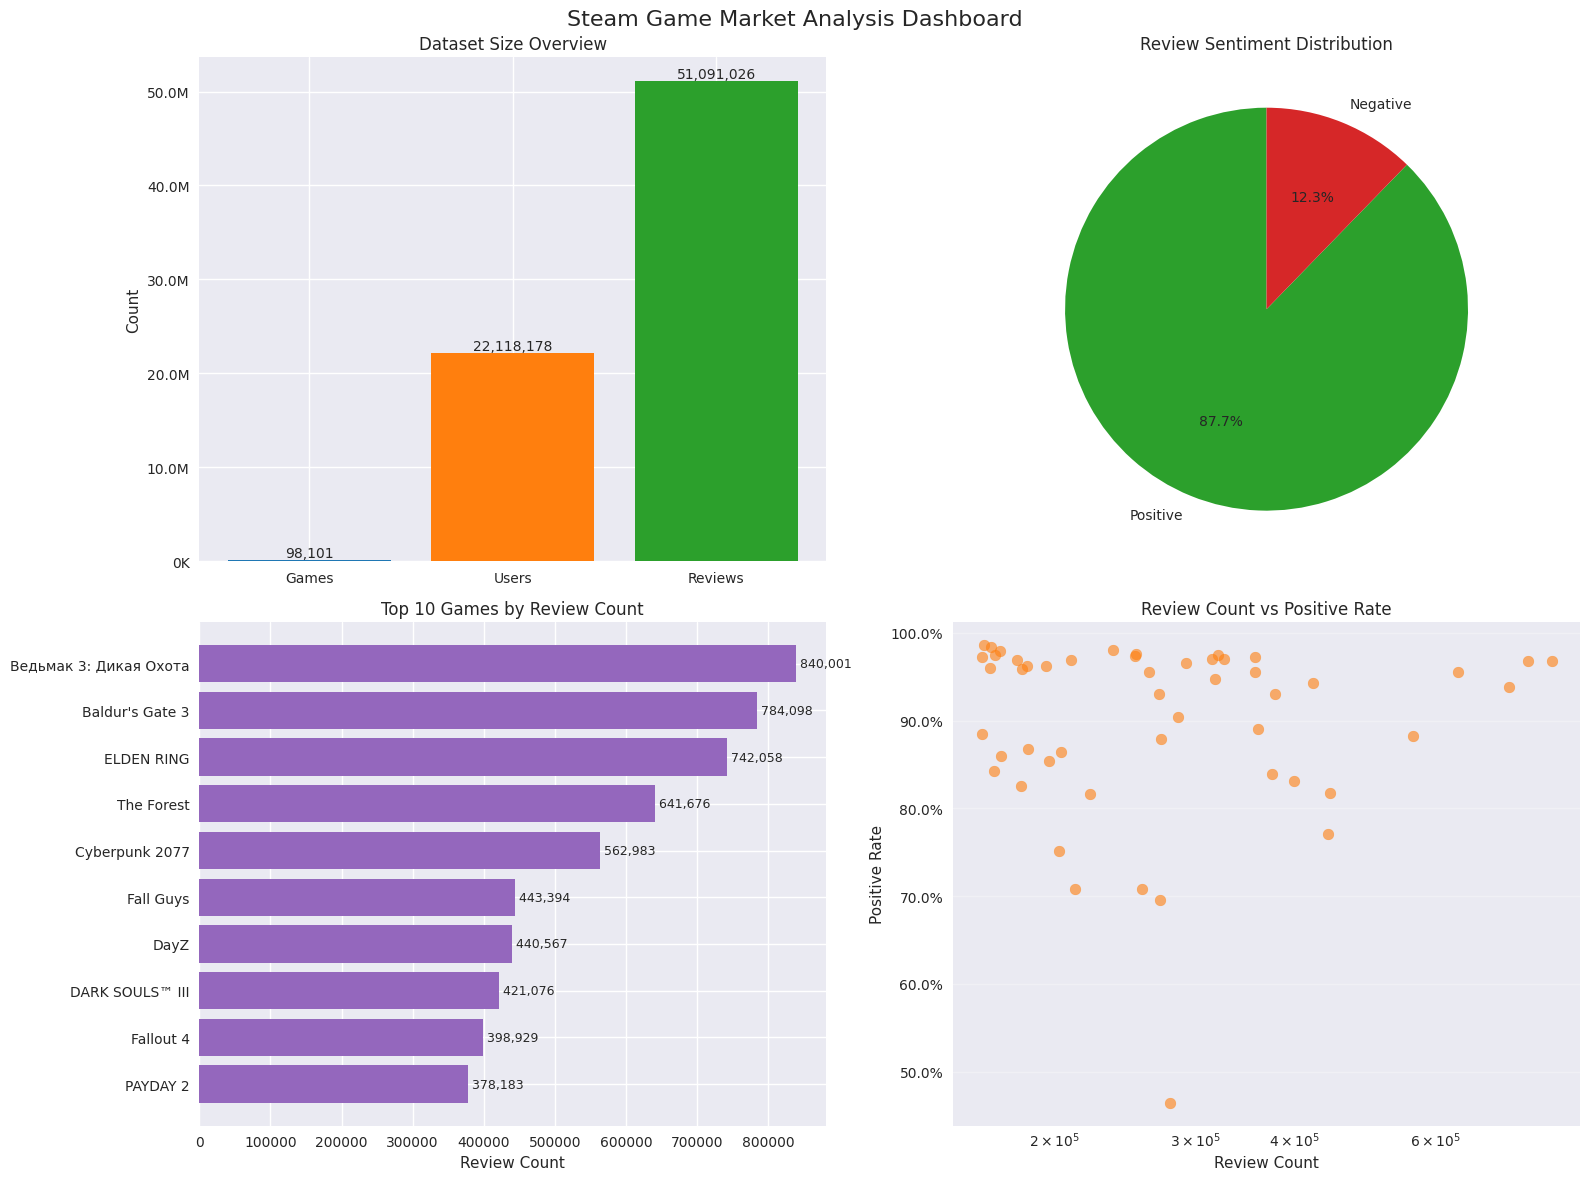

📊 Dashboard saved to analysis_plots/steam_market_dashboard.png


<Figure size 800x550 with 0 Axes>

In [ ]:
# Create comprehensive visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Steam Game Market Analysis Dashboard', fontsize=16, y=0.98)

# 1. Dataset Overview (Top Left)
labels = ['Games', 'Users', 'Reviews'] 
counts = [stats['Total Games'], stats['Total Users'], stats['Total Reviews']]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax1.bar(labels, counts, color=colors)
ax1.set_title('Dataset Size Overview')
ax1.set_ylabel('Count')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{count:,.0f}', ha='center', va='bottom')

# 2. Review Sentiment Distribution (Top Right)
sentiment_data = [stats['Positive Reviews'], stats['Negative Reviews']]
sentiment_labels = ['Positive', 'Negative']
sentiment_colors = ['#2ca02c', '#d62728']

wedges, texts, autotexts = ax2.pie(sentiment_data, labels=sentiment_labels, 
                                  colors=sentiment_colors, autopct='%1.1f%%', 
                                  startangle=90)
ax2.set_title('Review Sentiment Distribution')

# 3. Top Games by Review Count (Bottom Left)
top_10_games = top_games_data.head(10)
y_pos = np.arange(len(top_10_games))

bars = ax3.barh(y_pos, top_10_games['review_count'], color='#9467bd')
ax3.set_yticks(y_pos)
ax3.set_yticklabels([name[:25] + '...' if len(name) > 25 else name for name in top_10_games['name']])
ax3.set_xlabel('Review Count')
ax3.set_title('Top 10 Games by Review Count')
ax3.invert_yaxis()

# Add value labels
for i, (idx, row) in enumerate(top_10_games.iterrows()):
    ax3.text(row['review_count'], i, f" {row['review_count']:,}", 
            va='center', fontsize=9)

# 4. Review Count vs Positive Rate Scatter (Bottom Right)
scatter = ax4.scatter(top_games_data['review_count'], 
                     top_games_data['positive_rate'], 
                     alpha=0.6, s=60, c='#ff7f0e')
ax4.set_xlabel('Review Count')
ax4.set_ylabel('Positive Rate')
ax4.set_title('Review Count vs Positive Rate')
ax4.set_xscale('log')
ax4.grid(True, alpha=0.3)

# Format axes
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))

plt.tight_layout()
plt.show()

# Create output directory if it doesn't exist
output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

# Save the plot
plt.savefig(output_dir / 'steam_market_dashboard.png', dpi=300, bbox_inches='tight')
print(f"📊 Dashboard saved to {output_dir / 'steam_market_dashboard.png'}")

## Genre-Based Analysis

Analyze games by genre categories and market segments.

In [ ]:
print("🔍 Loading available genres from database...")
genre_check_query = """
SELECT 
    g.id as genre_id,
    g.name as genre_name,
    COUNT(gg.game_id) as game_count
FROM genres g
JOIN game_genres gg ON g.id = gg.genre_id
GROUP BY g.id, g.name
ORDER BY game_count DESC
"""

available_genres = pd.read_sql_query(genre_check_query, engine)
print("📊 Genres from database:")
print(available_genres.to_string(index=False))

# Create genre mapping from the normalized data
genre_mapping = {}
for _, row in available_genres.iterrows():
    genre_mapping[row['genre_id']] = row['genre_name']

print(f"\n✅ Created genre mapping with {len(genre_mapping)} genres")

🔍 Loading available genres from database...
📊 Genres from database:
genre_id            genre_name  game_count
      23                 Indie       64452
       4                Casual       39829
       1                Action       37020
      25             Adventure       36509
      28            Simulation       19298
       2              Strategy       17935
       3                   RPG       16548
      70          Early Access        8813
      18                Sports        4023
       9                Racing        3357
      29 Massively Multiplayer        1165
      57             Utilities         749
      53 Design & Illustration         449
      73               Violent         379
      51  Animation & Modeling         331
      54             Education         303
      58      Video Production         237
      74                  Gore         235
      37          Free To Play         233
      60      Game Development         219
      52      Audio Productio


🎯 Genre-Based Market Analysis

📊 Indie Games (Genre ID: 23)
   Games analyzed: 11991
   Total reviews: 20,430,694
   Avg positive rate: 78.6%
   Top rated game: TurnBreak

📊 Casual Games (Genre ID: 4)
   Games analyzed: 6207
   Total reviews: 5,423,094
   Avg positive rate: 79.2%
   Top rated game: DADOO: Twists, Turns, and Mischiefs

📊 Action Games (Genre ID: 1)
   Games analyzed: 7183
   Total reviews: 32,009,885
   Avg positive rate: 77.1%
   Top rated game: Fiz and the Rainbow Planet

📊 Adventure Games (Genre ID: 25)
   Games analyzed: 7415
   Total reviews: 21,161,496
   Avg positive rate: 78.3%
   Top rated game: Nina Aquila: Legal Eagle, Chapter IV: "Sacred Feathers"

📊 Simulation Games (Genre ID: 28)
   Games analyzed: 4201
   Total reviews: 10,292,454
   Avg positive rate: 74.7%
   Top rated game: Sudden Market

📊 Strategy Games (Genre ID: 2)
   Games analyzed: 3766
   Total reviews: 10,077,166
   Avg positive rate: 76.4%
   Top rated game: Headlong Hunt

📊 RPG Games (Genre I

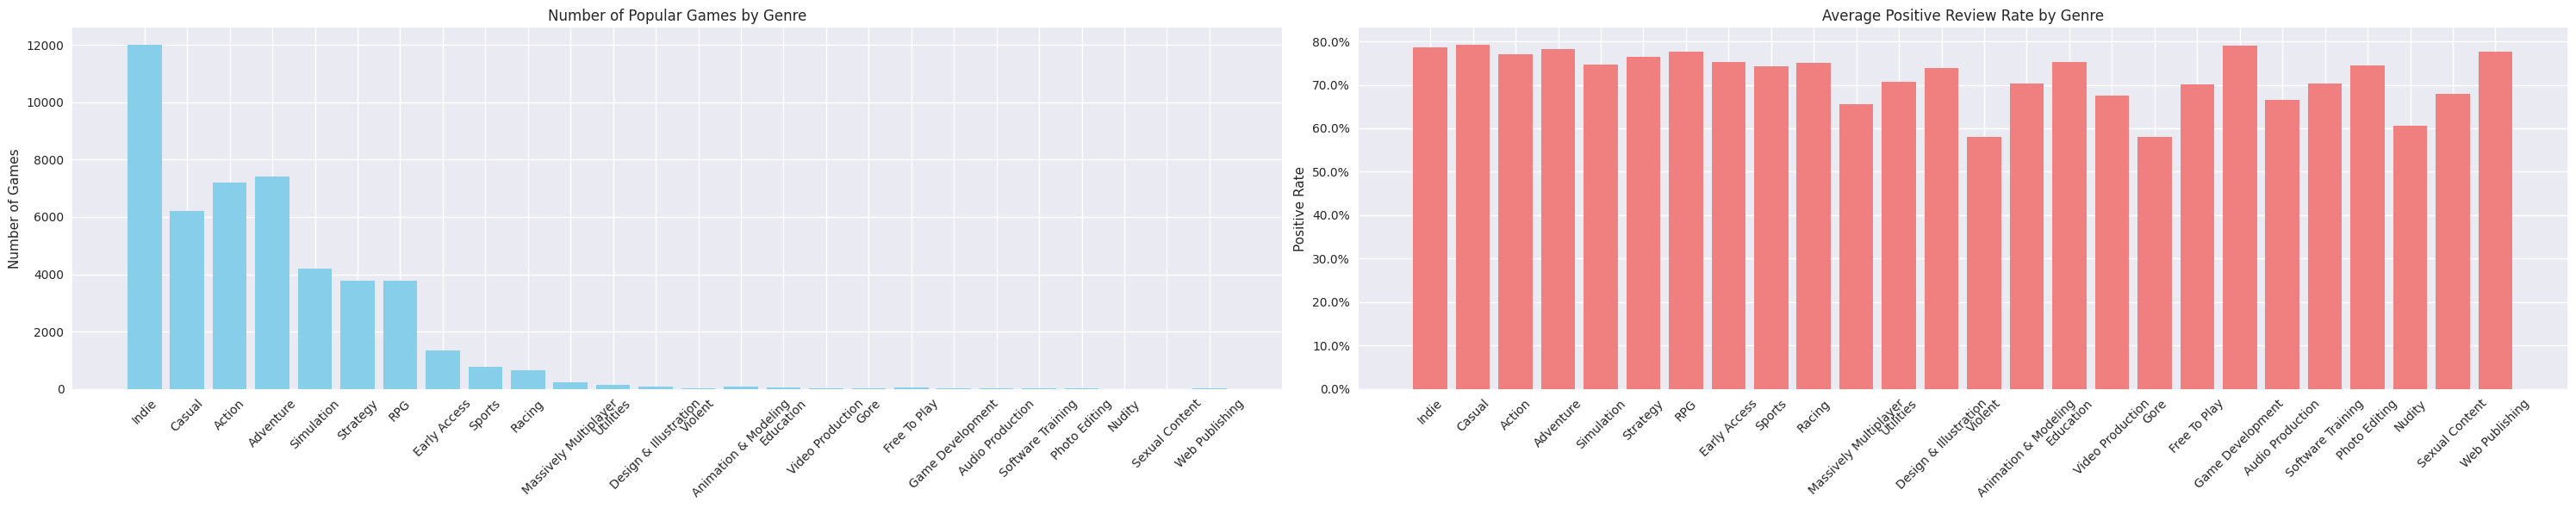

📊 Genre analysis saved to analysis_plots/genre_analysis.png
💾 Genre data exported to analysis_plots/genre_analysis.csv


<Figure size 800x550 with 0 Axes>

In [ ]:
# Genre analysis function using normalized tables
def analyze_genre(engine_or_conn, genre_id, min_reviews=50):
    """Analyze games by specific genre using normalized genre tables"""

    limit = -1

    query = f"""
    SELECT 
        g.name,
        g.game_id,
        COUNT(r.review_id) as review_count,
        AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as positive_rate,
        gen.name as genre_name
    FROM games g
    JOIN game_genres gg ON g.game_id = gg.game_id
    JOIN genres gen ON gg.genre_id = gen.id
    JOIN reviews r ON g.game_id = r.game_id
    WHERE gen.id = '{genre_id}'
    GROUP BY g.game_id, g.name, gen.name
    HAVING COUNT(r.review_id) >= {min_reviews}
    ORDER BY positive_rate DESC
    {f'LIMIT {limit}' if limit > 0 else ''}
    """

    return pd.read_sql_query(query, engine_or_conn)

# Analyze each genre
print(f"\n🎯 Genre-Based Market Analysis")
print("=" * 60)

genre_results = {}
for genre_id, genre_name in genre_mapping.items():
    try:
        genre_games = analyze_genre(engine, genre_id, min_reviews=20)

        if len(genre_games) > 0:
            genre_results[genre_name] = {
                'games_count': len(genre_games),
                'total_reviews': genre_games['review_count'].sum(),
                'avg_positive_rate': genre_games['positive_rate'].mean(),
                'top_game': genre_games.iloc[0]['name'] if len(genre_games) > 0 else 'N/A'
            }

            print(f"\n📊 {genre_name} Games (Genre ID: {genre_id})")
            print(f"   Games analyzed: {len(genre_games)}")
            print(f"   Total reviews: {genre_games['review_count'].sum():,}")
            print(f"   Avg positive rate: {genre_games['positive_rate'].mean():.1%}")
            print(f"   Top rated game: {genre_games.iloc[0]['name']}")
        else:
            print(f"\n❌ No games found for {genre_name} (Genre ID: {genre_id})")

    except Exception as e:
        print(f"\n❌ Error analyzing {genre_name}: {e}")


📈 Creating genre comparison visualization...


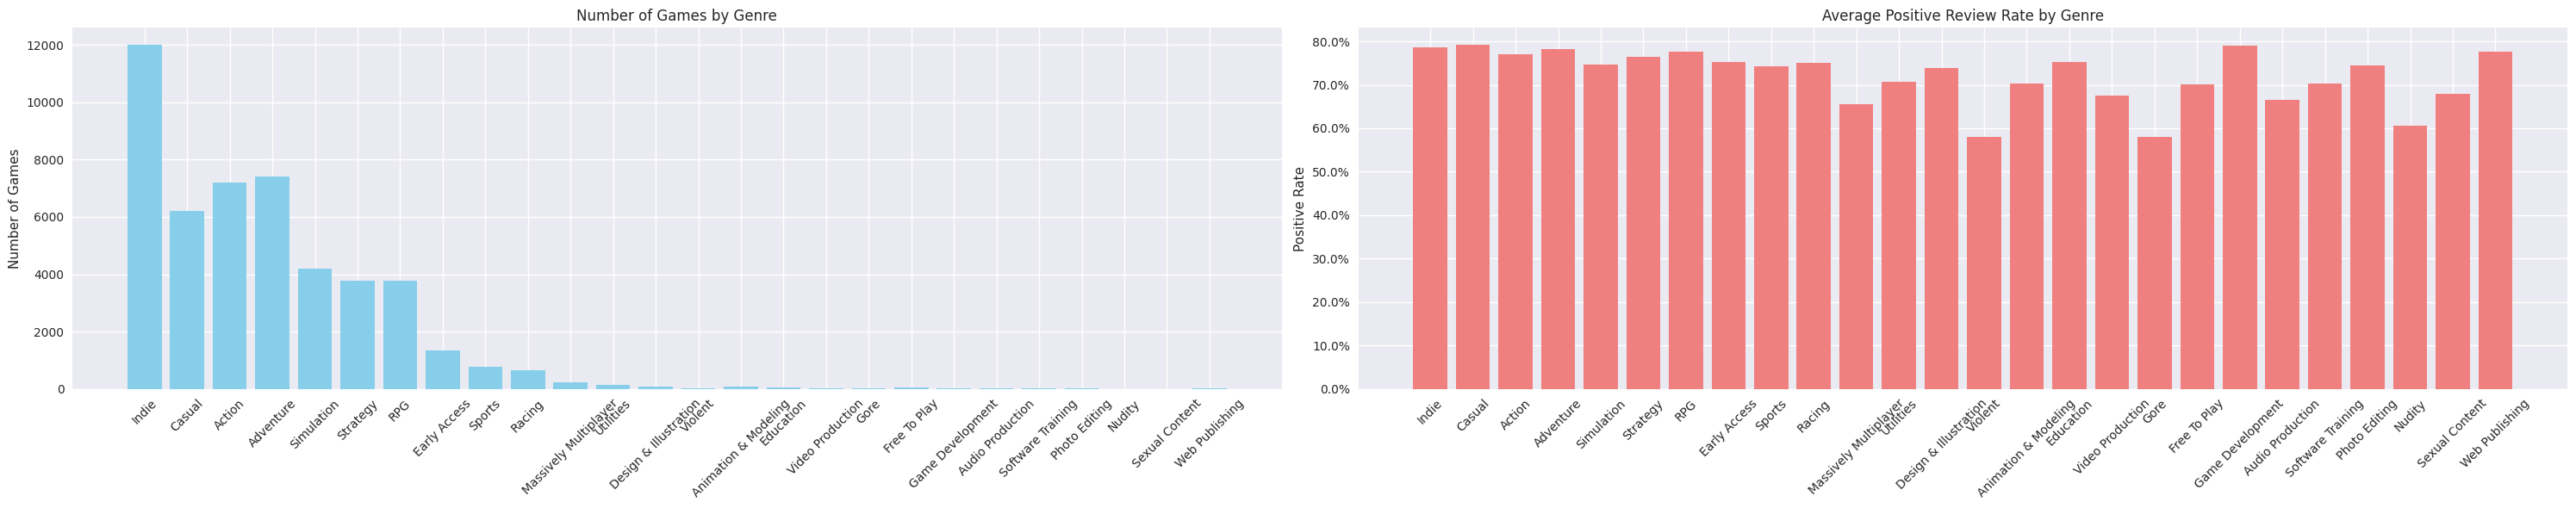

📊 Genre analysis saved to analysis_plots/genre_analysis.png
💾 Genre data exported to analysis_plots/genre_analysis.csv


<Figure size 800x550 with 0 Axes>

In [ ]:
# Create genre comparison visualization if we have results
if genre_results:
    print("\n📈 Creating genre comparison visualization...")

    genre_df = pd.DataFrame(genre_results).T
    genre_df.reset_index(inplace=True)
    genre_df.rename(columns={'index': 'genre'}, inplace=True)

    # Genre comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 6))

    # Games count by genre
    ax1.bar(genre_df['genre'], genre_df['games_count'], color='skyblue')
    ax1.set_title('Number of Games by Genre')
    ax1.set_ylabel('Number of Games')
    ax1.tick_params(axis='x', rotation=45)

    # Average positive rate by genre
    ax2.bar(genre_df['genre'], genre_df['avg_positive_rate'],
            color='lightcoral')
    ax2.set_title('Average Positive Review Rate by Genre')
    ax2.set_ylabel('Positive Rate')
    ax2.tick_params(axis='x', rotation=45)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))

    plt.tight_layout()
    plt.show()

    # Create output directory if it doesn't exist
    output_dir = Path("analysis_plots")
    output_dir.mkdir(exist_ok=True)

    # Save genre analysis
    plt.savefig(output_dir / 'genre_analysis.png',
                dpi=300, bbox_inches='tight')
    print(f"📊 Genre analysis saved to {output_dir / 'genre_analysis.png'}")

    # Export genre data to CSV
    genre_df.to_csv(output_dir / 'genre_analysis.csv', index=False)
    print(f"💾 Genre data exported to {output_dir / 'genre_analysis.csv'}")
else:
    print("\n⚠️  No genre data available for visualization")

## Advanced Genre Analysis with Normalized Tables

Now that we have normalized genre tables, we can perform more sophisticated analysis including cross-genre comparisons and genre popularity trends.

🎯 Advanced Genre Analysis with Normalized Tables
📊 Genre Market Share Analysis:
genre_id            genre_name  game_count  total_reviews  avg_positive_rate  market_share_pct
       1                Action       13153       32050698           0.870613             62.73
      25             Adventure       13029       21201417           0.868418             41.50
      23                 Indie       22514       20504804           0.890614             40.13
       3                   RPG        6137       15750672           0.870790             30.83
      28            Simulation        7016       10313244           0.872488             20.19
       2              Strategy        6555       10096232           0.878023             19.76
       4                Casual       13254        5471939           0.879981             10.71
      29 Massively Multiplayer         385        2513018           0.784620              4.92
      70          Early Access        2920        2349765        

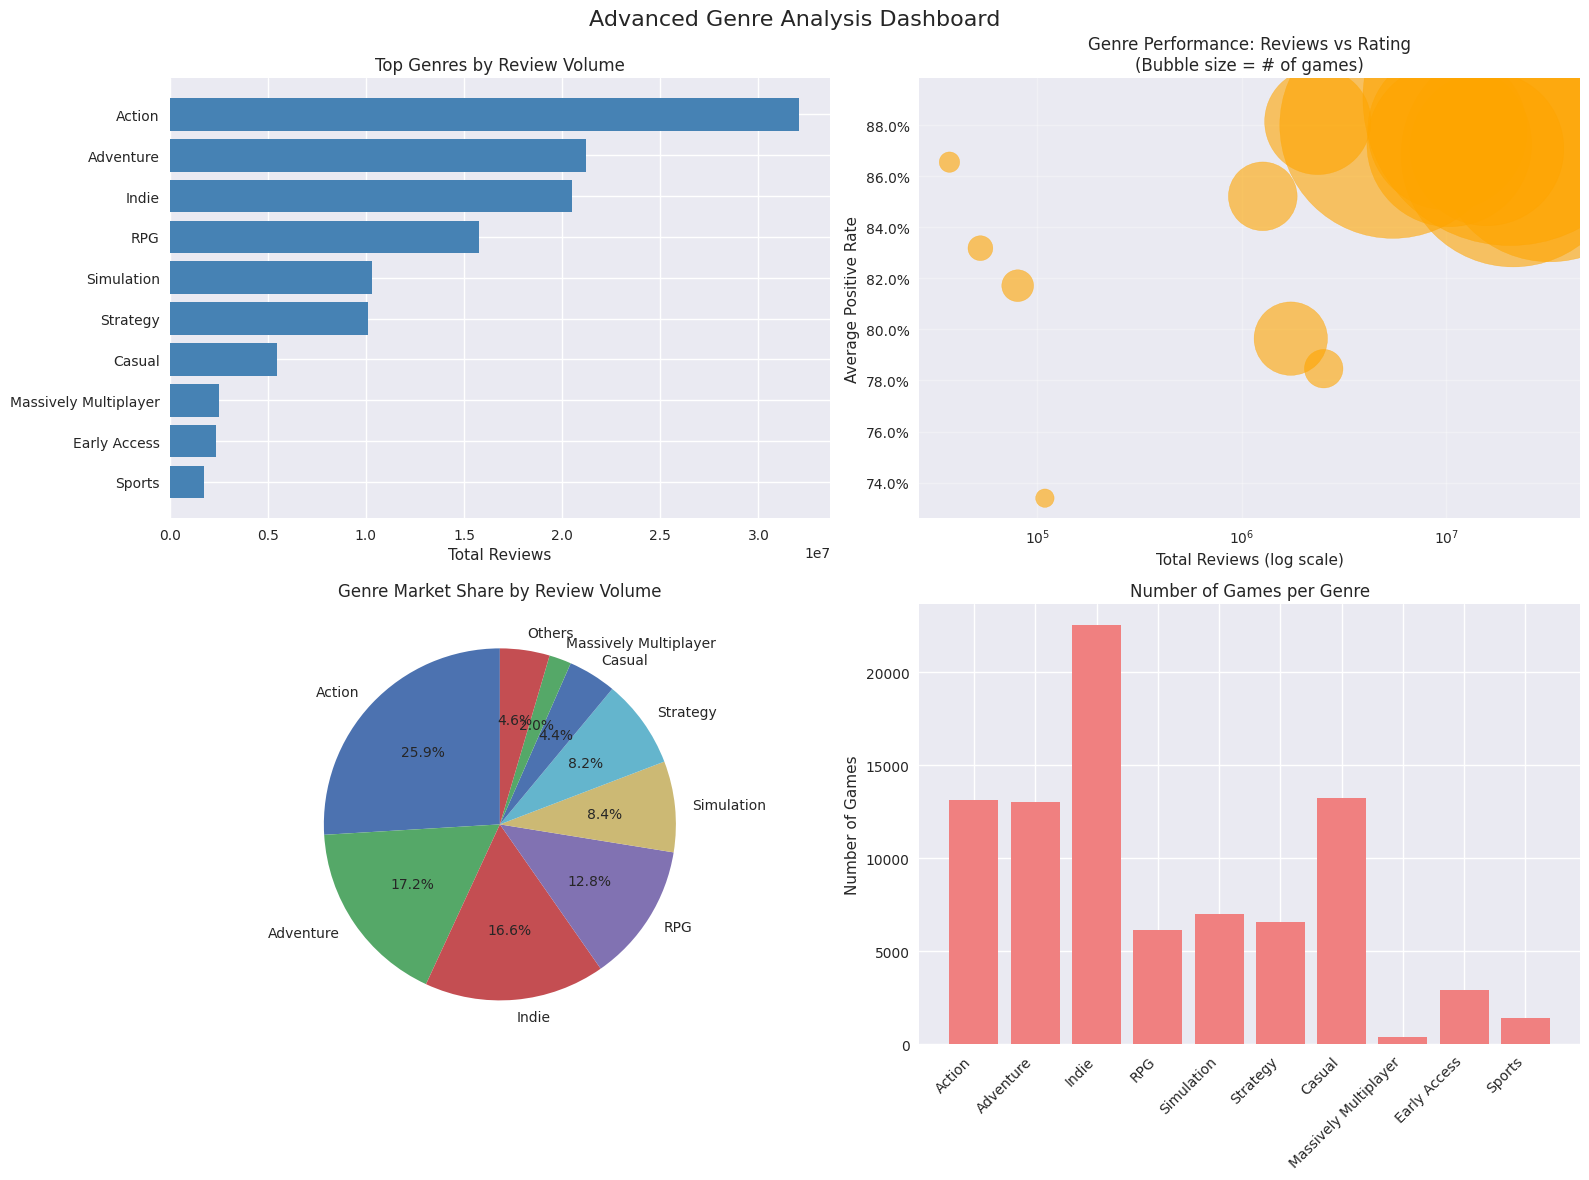

📊 Advanced genre analysis saved to analysis_plots/advanced_genre_analysis.png

🎮 Multi-Genre Games Analysis:


In [ ]:
# Advanced genre analysis using normalized tables
print("🎯 Advanced Genre Analysis with Normalized Tables")
print("=" * 60)

# 1. Genre popularity and market share analysis
genre_market_query = """
SELECT 
    g.id as genre_id,
    g.name as genre_name,
    COUNT(DISTINCT gg.game_id) as game_count,
    COUNT(r.review_id) as total_reviews,
    AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as avg_positive_rate,
    ROUND(COUNT(r.review_id) * 100.0 / (SELECT COUNT(*) FROM reviews), 2) as market_share_pct
FROM genres g
JOIN game_genres gg ON g.id = gg.genre_id
JOIN reviews r ON gg.game_id = r.game_id
GROUP BY g.id, g.name
HAVING COUNT(DISTINCT gg.game_id) >= 10  -- At least 10 games in genre
ORDER BY total_reviews DESC
LIMIT 15
"""

genre_market = pd.read_sql_query(genre_market_query, engine)
print("📊 Genre Market Share Analysis:")
print(genre_market.to_string(index=False))

# Create market share visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Genre Analysis Dashboard', fontsize=16, y=0.98)

# Top genres by review count
top_genres = genre_market.head(10)
ax1.barh(range(len(top_genres)), top_genres['total_reviews'], color='steelblue')
ax1.set_yticks(range(len(top_genres)))
ax1.set_yticklabels(top_genres['genre_name'])
ax1.set_xlabel('Total Reviews')
ax1.set_title('Top Genres by Review Volume')
ax1.invert_yaxis()

# Genre positive rate comparison
ax2.scatter(genre_market['total_reviews'], genre_market['avg_positive_rate'], 
           s=genre_market['game_count']*2, alpha=0.6, c='orange')
ax2.set_xlabel('Total Reviews (log scale)')
ax2.set_ylabel('Average Positive Rate')
ax2.set_title('Genre Performance: Reviews vs Rating\n(Bubble size = # of games)')
ax2.set_xscale('log')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1%}'))
ax2.grid(True, alpha=0.3)

# Market share pie chart (top 8)
top_8_genres = genre_market.head(8)
others_share = genre_market.iloc[8:]['market_share_pct'].sum() if len(genre_market) > 8 else 0

pie_data = list(top_8_genres['market_share_pct'])
pie_labels = list(top_8_genres['genre_name'])

if others_share > 0:
    pie_data.append(others_share)
    pie_labels.append('Others')

ax3.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
ax3.set_title('Genre Market Share by Review Volume')

# Games per genre distribution
ax4.bar(range(len(top_genres)), top_genres['game_count'], color='lightcoral')
ax4.set_xticks(range(len(top_genres)))
ax4.set_xticklabels(top_genres['genre_name'], rotation=45, ha='right')
ax4.set_ylabel('Number of Games')
ax4.set_title('Number of Games per Genre')

plt.tight_layout()
plt.show()

# Save advanced genre analysis
output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'advanced_genre_analysis.png', dpi=300, bbox_inches='tight')
print(f"📊 Advanced genre analysis saved to {output_dir / 'advanced_genre_analysis.png'}")

# 2. Multi-genre games analysis
print(f"\n🎮 Multi-Genre Games Analysis:")
multi_genre_query = """
SELECT 
    g.name as game_name,
    g.game_id,
    COUNT(gg.genre_id) as genre_count,
    STRING_AGG(gen.name, ', ' ORDER BY gen.name) as genres,
    COUNT(r.review_id) as review_count,
    AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as positive_rate
FROM games g
JOIN game_genres gg ON g.game_id = gg.game_id
JOIN genres gen ON gg.genre_id = gen.id
LEFT JOIN reviews r ON g.game_id = r.game_id
GROUP BY g.game_id, g.name
HAVING COUNT(gg.genre_id) >= 3  -- Games with 3+ genres
AND COUNT(r.review_id) >= 100   -- With decent review count
ORDER BY review_count DESC
LIMIT 15
"""

multi_genre = pd.read_sql_query(multi_genre_query, engine)
print("🏷️  Top Multi-Genre Games (3+ genres):")
print(multi_genre[['game_name', 'genre_count', 'genres', 'review_count', 'positive_rate']].to_string(index=False))

# 3. Genre correlation analysis
print(f"\n🔗 Genre Co-occurrence Analysis:")
genre_cooccurrence_query = """
SELECT 
    g1.name as genre1,
    g2.name as genre2,
    COUNT(*) as games_with_both,
    ROUND(COUNT(*) * 100.0 / (
        SELECT COUNT(DISTINCT game_id) 
        FROM game_genres gg1 
        WHERE gg1.genre_id = g1.id
    ), 1) as pct_of_genre1
FROM game_genres gg1
JOIN game_genres gg2 ON gg1.game_id = gg2.game_id AND gg1.genre_id < gg2.genre_id
JOIN genres g1 ON gg1.genre_id = g1.id  
JOIN genres g2 ON gg2.genre_id = g2.id
GROUP BY g1.id, g1.name, g2.id, g2.name
HAVING COUNT(*) >= 50  -- At least 50 games have both genres
ORDER BY games_with_both DESC
LIMIT 10
"""

genre_cooccurrence = pd.read_sql_query(genre_cooccurrence_query, engine)
print("🤝 Most Common Genre Combinations:")
print(genre_cooccurrence.to_string(index=False))

print("\n✅ Advanced genre analysis complete!")

## User Behavior Analysis

Analyze user review patterns and activity levels.

In [ ]:
# User behavior analysis
print("👥 User Behavior Analysis")
print("=" * 50)

# User activity distribution
user_activity_query = """
SELECT 
    games_reviewed,
    COUNT(*) as user_count
FROM (
    SELECT user_id, COUNT(DISTINCT game_id) as games_reviewed
    FROM reviews 
    GROUP BY user_id
    HAVING COUNT(DISTINCT game_id) <= 50  -- Focus on users with reasonable activity
) user_stats
GROUP BY games_reviewed
ORDER BY games_reviewed
"""

user_activity = pd.read_sql_query(user_activity_query, engine)
print(f"📊 User Activity Distribution (users who reviewed ≤50 games):")
print(user_activity.head(15).to_string(index=False))

# Most active users
most_active_query = """
SELECT 
    user_id,
    COUNT(DISTINCT game_id) as games_reviewed,
    COUNT(*) as total_reviews,
    AVG(CASE WHEN voted_up THEN 1.0 ELSE 0.0 END) as positivity_rate,
    SUM(CASE WHEN received_for_free THEN 1 ELSE 0 END) as free_game_reviews
FROM reviews 
GROUP BY user_id 
ORDER BY games_reviewed DESC 
LIMIT 10
"""

most_active = pd.read_sql_query(most_active_query, engine)
print(f"\n🏆 Top 10 Most Active Users:")
print(most_active.to_string(index=False))

# User sentiment patterns
user_sentiment_query = """
SELECT 
    CASE 
        WHEN positivity_rate >= 0.8 THEN 'Very Positive (80%+)'
        WHEN positivity_rate >= 0.6 THEN 'Positive (60-79%)'
        WHEN positivity_rate >= 0.4 THEN 'Mixed (40-59%)'
        ELSE 'Negative (<40%)'
    END as sentiment_category,
    COUNT(*) as user_count,
    AVG(review_count) as avg_reviews
FROM (
    SELECT 
        user_id,
        COUNT(*) as review_count,
        AVG(CASE WHEN voted_up THEN 1.0 ELSE 0.0 END) as positivity_rate
    FROM reviews 
    GROUP BY user_id
    HAVING COUNT(*) >= 5  -- Users with at least 5 reviews
) user_sentiment
GROUP BY sentiment_category
ORDER BY 
    CASE sentiment_category
        WHEN 'Very Positive (80%+)' THEN 1
        WHEN 'Positive (60-79%)' THEN 2
        WHEN 'Mixed (40-59%)' THEN 3
        ELSE 4
    END
"""

user_sentiment = pd.read_sql_query(user_sentiment_query, engine)
print(f"\n😊 User Sentiment Distribution (users with 5+ reviews):")
print(user_sentiment.to_string(index=False))

# Visualize user behavior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# User activity distribution (log scale)
activity_subset = user_activity[user_activity['games_reviewed'] <= 20]  # Focus on reasonable range
ax1.bar(activity_subset['games_reviewed'], activity_subset['user_count'], alpha=0.7, color='steelblue')
ax1.set_xlabel('Number of Games Reviewed')
ax1.set_ylabel('Number of Users')
ax1.set_title('User Activity Distribution')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# User sentiment distribution
ax2.pie(user_sentiment['user_count'], labels=user_sentiment['sentiment_category'], 
        autopct='%1.1f%%', startangle=90)
ax2.set_title('User Sentiment Distribution\n(Users with 5+ reviews)')

plt.tight_layout()
plt.show()

# Save user behavior analysis
plt.savefig(output_dir / 'user_behavior_analysis.png', dpi=300, bbox_inches='tight')
print(f"📊 User behavior analysis saved to {output_dir / 'user_behavior_analysis.png'}")

# Export user data
user_activity.to_csv(output_dir / 'user_activity_distribution.csv', index=False)
user_sentiment.to_csv(output_dir / 'user_sentiment_distribution.csv', index=False)
print(f"💾 User data exported to CSV files")

## Market Concentration Analysis

Analyze market concentration using Gini coefficient and Lorenz curves.

📊 Market Concentration Analysis
📈 Market Concentration Metrics:
Gini Coefficient          0.955
Top 1% games share        64.3%
Top 5% games share        89.0%
Top 10% games share       94.9%

🎮 Review Distribution:
Total games with reviews  32,970
Total reviews             51,091,026
Average reviews per game  1549.6
Median reviews per game   24


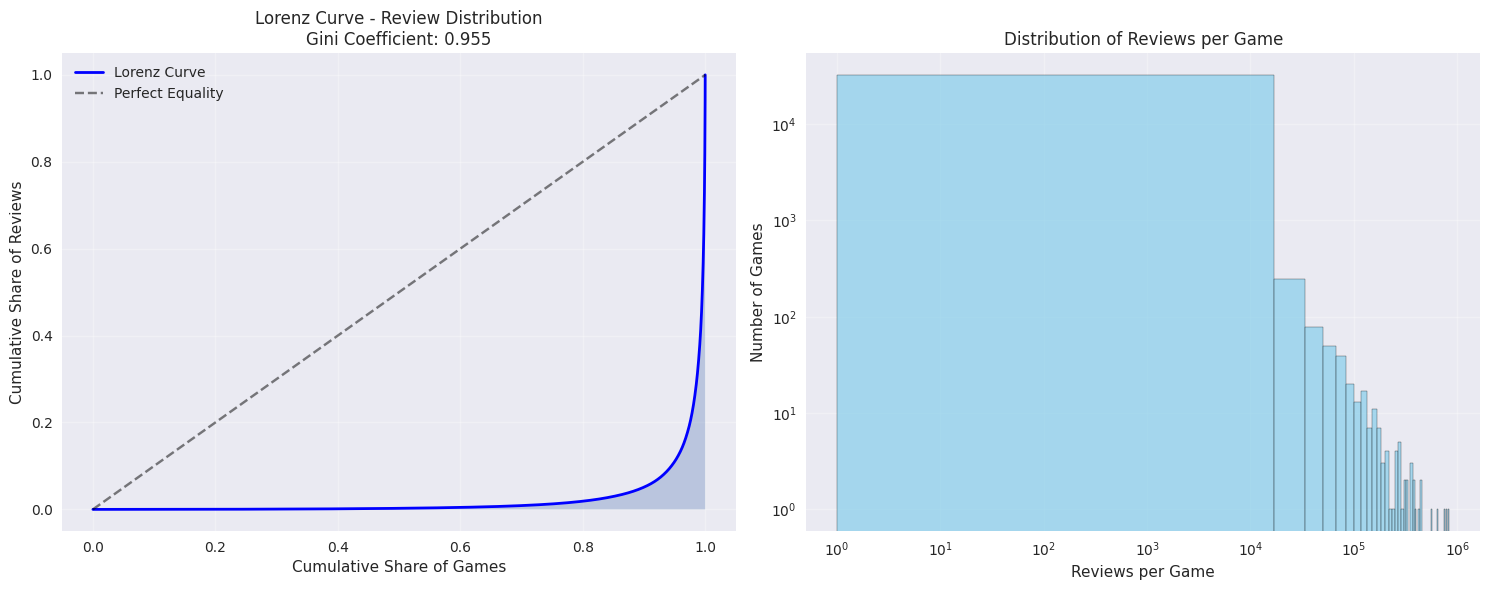

📊 Market concentration analysis saved to analysis_plots/market_concentration_analysis.png
💾 Concentration metrics exported to analysis_plots/market_concentration_metrics.csv


<Figure size 800x550 with 0 Axes>

In [ ]:
# Market concentration analysis
def calculate_gini_coefficient(data):
    """Calculate Gini coefficient for measuring inequality"""
    data = np.array(data)
    data = np.sort(data)
    n = len(data)
    cumsum = np.cumsum(data)
    
    # Gini coefficient formula
    gini = (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n
    return gini

def create_lorenz_curve(data, title="Lorenz Curve"):
    """Create Lorenz curve for inequality visualization"""
    data = np.sort(data)
    n = len(data)
    
    # Calculate cumulative percentages
    cumulative_population = np.arange(1, n + 1) / n
    cumulative_wealth = np.cumsum(data) / np.sum(data)
    
    return cumulative_population, cumulative_wealth

print("📊 Market Concentration Analysis")
print("=" * 50)

# Get review distribution by game
game_reviews_query = """
SELECT 
    game_id,
    COUNT(*) as review_count
FROM reviews 
GROUP BY game_id 
ORDER BY review_count DESC
"""

game_reviews = pd.read_sql_query(game_reviews_query, engine)
review_counts = game_reviews['review_count'].values

# Calculate market concentration metrics
gini_coeff = calculate_gini_coefficient(review_counts)
total_reviews = review_counts.sum()

# Top percentiles
top_1_percent = int(len(review_counts) * 0.01)
top_5_percent = int(len(review_counts) * 0.05)
top_10_percent = int(len(review_counts) * 0.10)

top_1_share = review_counts[:top_1_percent].sum() / total_reviews
top_5_share = review_counts[:top_5_percent].sum() / total_reviews 
top_10_share = review_counts[:top_10_percent].sum() / total_reviews

print(f"📈 Market Concentration Metrics:")
print(f"{'Gini Coefficient':<25} {gini_coeff:.3f}")
print(f"{'Top 1% games share':<25} {top_1_share:.1%}")
print(f"{'Top 5% games share':<25} {top_5_share:.1%}")
print(f"{'Top 10% games share':<25} {top_10_share:.1%}")

print(f"\n🎮 Review Distribution:")
print(f"{'Total games with reviews':<25} {len(review_counts):,}")
print(f"{'Total reviews':<25} {total_reviews:,}")
print(f"{'Average reviews per game':<25} {total_reviews/len(review_counts):.1f}")
print(f"{'Median reviews per game':<25} {np.median(review_counts):.0f}")

# Create Lorenz curve visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Lorenz curve
population_pct, wealth_pct = create_lorenz_curve(review_counts)
ax1.plot(population_pct, wealth_pct, 'b-', linewidth=2, label='Lorenz Curve')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect Equality')
ax1.fill_between(population_pct, wealth_pct, alpha=0.3)
ax1.set_xlabel('Cumulative Share of Games')
ax1.set_ylabel('Cumulative Share of Reviews') 
ax1.set_title(f'Lorenz Curve - Review Distribution\nGini Coefficient: {gini_coeff:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Review distribution histogram (log scale)
ax2.hist(review_counts, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax2.set_xlabel('Reviews per Game')
ax2.set_ylabel('Number of Games')
ax2.set_title('Distribution of Reviews per Game')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save concentration analysis
plt.savefig(output_dir / 'market_concentration_analysis.png', dpi=300, bbox_inches='tight')
print(f"📊 Market concentration analysis saved to {output_dir / 'market_concentration_analysis.png'}")

# Export concentration metrics
concentration_metrics = {
    'Metric': ['Gini Coefficient', 'Top 1% Share', 'Top 5% Share', 'Top 10% Share', 
               'Total Games', 'Total Reviews', 'Avg Reviews/Game', 'Median Reviews/Game'],
    'Value': [gini_coeff, top_1_share, top_5_share, top_10_share,
              len(review_counts), total_reviews, total_reviews/len(review_counts), np.median(review_counts)]
}

concentration_df = pd.DataFrame(concentration_metrics)
concentration_df.to_csv(output_dir / 'market_concentration_metrics.csv', index=False)
print(f"💾 Concentration metrics exported to {output_dir / 'market_concentration_metrics.csv'}")

## Custom Queries and Analysis

Execute custom SQL queries for specific research questions.

In [ ]:
# Custom analysis queries
print("🔍 Custom Analysis Queries")
print("=" * 50)

# 1. Games with most polarized reviews (high volume, mixed sentiment)
polarized_games_query = """
SELECT 
    g.name,
    g.game_id,
    COUNT(r.review_id) as total_reviews,
    AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as positive_rate,
    ABS(AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) - 0.5) as polarization_score
FROM games g 
JOIN reviews r ON g.game_id = r.game_id 
GROUP BY g.game_id, g.name 
HAVING COUNT(r.review_id) >= 1000
ORDER BY polarization_score ASC, total_reviews DESC
LIMIT 10
"""

polarized_games = pd.read_sql_query(polarized_games_query, engine)
print("🎭 Most Polarized Games (mixed sentiment with high volume):")
print(polarized_games.to_string(index=False))

# 2. Free vs Paid games performance comparison
free_vs_paid_query = """
SELECT 
    CASE WHEN r.received_for_free THEN 'Free' ELSE 'Paid' END as game_type,
    COUNT(DISTINCT g.game_id) as unique_games,
    COUNT(r.review_id) as total_reviews,
    AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as avg_positive_rate,
    AVG(review_count) as avg_reviews_per_game
FROM games g 
JOIN reviews r ON g.game_id = r.game_id 
JOIN (
    SELECT game_id, COUNT(*) as review_count 
    FROM reviews 
    GROUP BY game_id
) rc ON g.game_id = rc.game_id
GROUP BY r.received_for_free
"""

free_vs_paid = pd.read_sql_query(free_vs_paid_query, engine)
print(f"\n💰 Free vs Paid Games Comparison:")
print(free_vs_paid.to_string(index=False))

# 3. Network analysis - Games often reviewed together
shared_reviewers_query = """
SELECT 
    g1.name as game1_name,
    g2.name as game2_name,
    shared_users as shared_reviewers,
    g1_reviews,
    g2_reviews,
    ROUND(shared_users * 1.0 / LEAST(g1_reviews, g2_reviews), 3) as overlap_ratio
FROM (
    SELECT 
        r1.game_id as game1_id,
        r2.game_id as game2_id,
        COUNT(*) as shared_users
    FROM reviews r1 
    JOIN reviews r2 ON r1.user_id = r2.user_id AND r1.game_id < r2.game_id
    GROUP BY r1.game_id, r2.game_id 
    HAVING COUNT(*) >= 50
    ORDER BY shared_users DESC
    LIMIT 15
) shared
JOIN (SELECT game_id, COUNT(*) as g1_reviews FROM reviews GROUP BY game_id) c1 
    ON shared.game1_id = c1.game_id
JOIN (SELECT game_id, COUNT(*) as g2_reviews FROM reviews GROUP BY game_id) c2 
    ON shared.game2_id = c2.game_id
JOIN games g1 ON shared.game1_id = g1.game_id
JOIN games g2 ON shared.game2_id = g2.game_id
ORDER BY shared_users DESC
"""

try:
    shared_reviewers = pd.read_sql_query(shared_reviewers_query, engine)
    print(f"\n🤝 Games with Most Shared Reviewers:")
    print(shared_reviewers.to_string(index=False))
except Exception as e:
    print(f"\n⚠️  Network analysis query too complex for current dataset: {e}")

# 4. Temporal patterns using created_at timestamps
print(f"\n📅 Temporal Analysis:")
temporal_query = """
SELECT 
    DATE_TRUNC('month', created_at) as month,
    COUNT(*) as reviews_count,
    AVG(CASE WHEN voted_up THEN 1.0 ELSE 0.0 END) as positive_rate
FROM reviews
WHERE created_at IS NOT NULL
GROUP BY month
ORDER BY month DESC
LIMIT 12
"""

try:
    temporal_data = pd.read_sql_query(temporal_query, engine)
    if len(temporal_data) > 0:
        print("Recent review activity by month:")
        print(temporal_data.to_string(index=False))
    else:
        print("No temporal data available (created_at timestamps not populated)")
except Exception as e:
    print(f"Temporal analysis not available: {e}")

# Custom query playground - Users can modify this
print(f"\n🛠️ Custom Query Playground:")
print("Modify the query below to explore specific research questions:")

# Example: Users can change this query
custom_query = """
SELECT 
    g.name,
    COUNT(r.review_id) as review_count,
    AVG(CASE WHEN r.voted_up THEN 1.0 ELSE 0.0 END) as positive_rate
FROM games g 
JOIN reviews r ON g.game_id = r.game_id 
WHERE g.name ILIKE '%Counter%' OR g.name ILIKE '%Strike%'
GROUP BY g.game_id, g.name 
ORDER BY review_count DESC
"""

try:
    custom_result = pd.read_sql_query(custom_query, engine)
    print("🎯 Custom Query Results (Counter-Strike related games):")
    print(custom_result.to_string(index=False))
except Exception as e:
    print(f"❌ Custom query error: {e}")

## Summary and Export Results

Summarize key findings and export analysis results.

In [ ]:
# Summary of key findings
print("🎯 Steam Game Market Analysis - Key Findings")
print("=" * 60)

# Compile key statistics
key_findings = {
    "Dataset Scale": {
        "Total Games": f"{stats['Total Games']:,}",
        "Total Users": f"{stats['Total Users']:,}",
        "Total Reviews": f"{stats['Total Reviews']:,}",
    },
    "Market Sentiment": {
        "Positive Review Rate": f"{positive_rate:.1f}%",
        "Free Game Review Rate": f"{free_game_rate:.1f}%",
    },
    "Market Concentration": {
        "Gini Coefficient": f"{gini_coeff:.3f}",
        "Top 1% Games Market Share": f"{top_1_share:.1%}",
        "Top 10% Games Market Share": f"{top_10_share:.1%}",
    },
    "Top Performing Game": {
        "Most Reviewed": top_games_data.iloc[0]['name'] if len(top_games_data) > 0 else "N/A",
        "Review Count": f"{top_games_data.iloc[0]['review_count']:,}" if len(top_games_data) > 0 else "N/A",
        "Positive Rate": f"{top_games_data.iloc[0]['positive_rate']:.1%}" if len(top_games_data) > 0 else "N/A"
    }
}

for category, metrics in key_findings.items():
    print(f"\n📊 {category}:")
    for metric, value in metrics.items():
        print(f"   {metric:<25} {value}")

# Export comprehensive results
print(f"\n💾 Exporting Analysis Results:")
print(f"   Output directory: {output_dir}")

# List all generated files
output_files = list(output_dir.glob("*"))
for file_path in sorted(output_files):
    file_size = file_path.stat().st_size / 1024  # KB
    print(f"   ✓ {file_path.name} ({file_size:.1f} KB)")

# Create a summary report
summary_report = {
    "Analysis Date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S"),
    "Database Path": db_path,
    "Database Size (MB)": f"{db_size:.1f}",
    **{f"Dataset.{k}": v for k, v in key_findings["Dataset Scale"].items()},
    **{f"Sentiment.{k}": v for k, v in key_findings["Market Sentiment"].items()},
    **{f"Concentration.{k}": v for k, v in key_findings["Market Concentration"].items()},
    **{f"TopGame.{k}": v for k, v in key_findings["Top Performing Game"].items()},
}

# Save summary as JSON and CSV
summary_df = pd.DataFrame([summary_report])
summary_df.to_csv(output_dir / 'analysis_summary.csv', index=False)

import json
with open(output_dir / 'analysis_summary.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print(f"\n✅ Analysis Complete!")
print(f"📁 All results saved to: {output_dir}")
print(f"📊 Generated {len(output_files)} files")
print(f"🎮 Key insight: Market shows {gini_coeff:.3f} Gini coefficient concentration")
print(f"⭐ Top game: {top_games_data.iloc[0]['name']} with {top_games_data.iloc[0]['review_count']:,} reviews")

## Close Database Connection

Properly close the database connection and clean up resources.

In [ ]:
# Close database connection and cleanup
try:
    if 'conn' in locals() and conn:
        conn.close()
        print("✅ PostgreSQL connection closed successfully")
    
    if 'engine' in locals() and engine:
        engine.dispose()
        print("✅ SQLAlchemy engine disposed successfully")
        
    print("ℹ️  Database connections cleaned up")
        
except Exception as e:
    print(f"⚠️  Error closing database connections: {e}")

# Final memory cleanup
import gc
gc.collect()

print(f"\n🎉 Steam Market Analysis Complete!")
print(f"📊 Generated comprehensive analysis with visualizations")
print(f"💾 Results exported to: {output_dir}")
print(f"🔬 Ready for further research and insights")

# Instructions for next steps
print(f"\n📋 Next Steps:")
print(f"   1. Review generated plots in {output_dir}")
print(f"   2. Examine exported CSV data for detailed analysis") 
print(f"   3. Modify custom queries above for specific research questions")
print(f"   4. Use genre filtering for targeted market segments")
print(f"   5. Consider network analysis using shared reviewer data")
print(f"\n🐘 PostgreSQL Database Info:")
print(f"   • Connection: {DB_HOST}:{DB_PORT}/{DB_NAME}")
print(f"   • Use psql or pgAdmin for direct database access")
print(f"   • Analysis queries saved to: analysis_queries.sql")